# 🧠 AI & Machine Learning Lab 17 -- Classification Intuition

**Instructor:** Azeem Aslam<br>
**Duration:** 4–5 Hours<br>
**Level:** Beginner → Intermediate<br>
**Tools:** Python, Pandas, NumPy, Matplotlib, scikit-learn


# 🎯 Lab Objectives

In this lab, students will learn:

* What classification is
* Regression vs classification difference
* Features vs labels
* Binary classification concept
* Dataset loading
* EDA for classification data
* Training a classification model
* Prediction workflow
* Evaluation basics

By the end of this lab, students will build their **first classification system**.


# 📦 Dataset for This Lab

Today we will use:

**Breast Cancer Wisconsin Dataset (built-in sklearn dataset)**

Why this dataset?

* Real medical dataset
* Binary classification problem
* Clean and ready to use
* Widely used in ML education

Students do NOT need to download anything.

Later labs will use:

* Kaggle datasets
* UCI datasets
* Real CSV files

# PART 1 — Import Libraries


In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import load_breast_cancer

# PART 2 — Load Dataset

In [5]:
data = load_breast_cancer()

This dataset contains **medical measurements** used to classify tumors.


In [6]:
X = data.data
y = data.target

```python
data = load_breast_cancer()

X = data.data
y = data.target
```

Step-by-step:

**data = load_breast_cancer()**<br>
Is line me hum **scikit-learn ki built-in dataset** load kar rahe hain.
Ye ek **Breast Cancer classification dataset** hai jo machine learning practice ke liye use hoti hai.

Is dataset ke andar already:

* features (input values)
* labels (output / classes)
  maujood hotay hain.

---

**X = data.data**<br>
Yahan hum **features (input variables)** nikaal rahe hain.

Matlab:<br>
Ye wo **measurements** hain jo model ko di jayengi.

Example:

* cell radius
* texture
* perimeter
* area
* waghera

Simple words me:

> **X = model ka input data**

---

**y = data.target**<br>
Yahan hum **labels / output classes** nikaal rahe hain.

Is dataset me:

* `0 = malignant`
* `1 = benign`

Simple words me:

> **y = model ka answer / prediction target**

---

Agar ML ke perspective se dekho:

```
X → input features
y → output labels
```

Ye har **supervised learning classification problem** ka standard pattern hota hai.

# PART 3 — Convert Dataset to DataFrame (EDA Step) 🔍

In [8]:
df = pd.DataFrame(X , columns=data.feature_names)

In [9]:
df["target"] = y

In [11]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Students should observe:

* feature columns
* target column

# PART 4 — Dataset Exploration

## Shape


In [12]:
df.shape

(569, 31)

## Class Distribution

In [33]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Students observe:

* Feature ranges are very different
* Some features have values ~0.1
* Some features have values ~1000

This is why scaling is required.

In [13]:
df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

This shows:

* 0 = malignant
* 1 = benign

This is a **binary classification dataset**.

# PART 5 — Features vs Labels 🧠

Features:

```
input measurements
```

Label:

```
cancer diagnosis
```

Machine learning notation:

```
X → features
y → label
```



# PART 6 — Visualization (Matplotlib) 📊

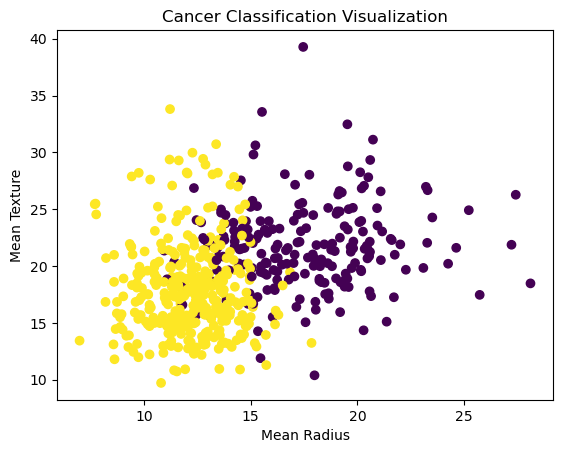

In [15]:
plt.scatter(df["mean radius"] , df["mean texture"] , c=df["target"])
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Cancer Classification Visualization")
plt.show()



Code dekho:

```python
plt.scatter(df["mean radius"], df["mean texture"], c=df["target"])
```

Ye **scatter plot** bana raha hai.

Iska matlab:

* **mean radius → x-axis**
* **mean texture → y-axis**
* **c=df["target"] → color decide karega**

---

### Graph kyu banaya?

Graph ka purpose hai:

> dekhna ke cancer ki dono classes features me visually separate ho rahi hain ya nahi.

Machine learning me isay **data visualization / EDA** kehte hain.

Agar points alag clusters me nazar aayen, to classification model ke liye problem easy hoti hai.

---

### `c = df["target"]` ka kya use hai?

Ye **colors assign karta hai classes ke hisaab se**.

Matlab:

* target = 0 → ek color
* target = 1 → dusra color

Agar ye line na ho:

```python
plt.scatter(df["mean radius"], df["mean texture"])
```

toh **sab points same color ke honge**, aur classes ka difference nazar nahi aayega.

---

### Simple real-life example

Socho tum students ka graph bana rahe ho:

* x-axis = height
* y-axis = weight
* color = male/female

Toh color batata hai **kaun si category hai**.

Yahan bhi wahi ho raha hai — sirf **cancer classes ke sath**.

---




### We observe:
👉 Classes look somewhat separable.<br>
👉 Not perfectly linear, but Logistic Regression can still perform well.<br>

Polynomial features?<br>
For this dataset:

* Linear model performs very well already.
* Polynomial not necessary initially.
* We can test later.

Important lesson:<br>
Never blindly apply polynomial features.

# PART 7 — Decision Boundary Concept

A classification model tries to draw a line separating classes.

This line is called:

> Decision Boundary

This idea is central to classification algorithms.


# PART 8 — Train/Test Split (Very Important) 🚨

Why we split data:<br>
If we train and test on the same data, the model can **memorize** instead of learning.

We split data into:

* training set
* testing set

We will use **80/20 split**.

In [17]:
from sklearn.model_selection import train_test_split

In [22]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , train_size = 0.8 , random_state=42
)

Check shapes:


In [23]:
print(X_train.shape)

(455, 30)


In [24]:
print(X_test.shape)

(114, 30)


**Students now understand:**<br>
Training data ≠ Testing data.


# ⚖️ PART 9 — Feature Scaling (CRITICAL STEP)

We scale AFTER splitting.

Why?<br>
Because scaling before splitting causes data leakage.


In [34]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()

In [42]:
X_train_scaled = scaler.fit_transform(X_train)

In [44]:
X_test_scaled = scaler.transform(X_test)

Important:

* fit() only on training data
* transform() on test data

This prevents leakage.

## 🔹 Pehli line

```python
scaler = StandardScaler()
```

Is line ka matlab:

> Hum ek machine bana rahe hain jo data ko **scale / normalize** karegi.

StandardScaler kya karta hai?

Ye har feature ko is form me convert karta hai:

```
Mean = 0
Standard Deviation = 1
```

Simple words me:

> Sab features ko ek hi level pe le aata hai taake koi feature zyada heavy na ho.

---

## 🔹 Dusri line

```python
X_train_scaled = scaler.fit_transform(X_train)
```

Yahan 2 kaam ho rahe hain:

### 1️⃣ fit()

Scaler training data ka:

* mean calculate karta hai
* standard deviation calculate karta hai

### 2️⃣ transform()

Phir formula apply karta hai:

```
X_scaled = (X - mean) / std
```

Important baat:

⚠ Ye sirf **training data pe fit hota hai**

---

## 🔹 Teesri line

```python
X_test_scaled = scaler.transform(X_test)
```

Yahan sirf:

👉 transform ho raha hai
👉 fit nahi ho raha

Kyun?

Kyuki:

> Test data future data hota hai
> Uska mean nikalna cheating hoti hai ❌

Is liye:

* Training ka mean use hoga
* Training ka std use hoga

---

## 🔥 Simple real-life example

Socho class me:

* Train students ka average height nikala
* Us base pe sab ko compare kiya

Ab exam me naye students aaye
Toh tum unka average alag se nahi nikaloge —
balki pehle wali class ke standard pe compare karoge.

Ye hi scaling me ho raha hai.

---

## 🔑 Golden Rule

```
Training → fit + transform
Testing → only transform
```

Kabhi bhi:

```
scaler.fit(X_test)
```

Nahi karna ❌


# PART 10 — Train Classification Model 🤖

In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
model = LogisticRegression(max_iter=5000)

In [48]:
model.fit(X_train_scaled , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


# PART 11 — Predictions

## Training predictions


In [51]:
from sklearn.metrics import accuracy_score , confusion_matrix

### Training Accuracy

In [52]:
train_pred = model.predict(X_train_scaled)

In [53]:
accuracy = accuracy_score(y_train , train_pred)

In [54]:
print("Train Accuracy : " , accuracy)

Train Accuracy :  0.9868131868131869


## Testing predictions

In [55]:
test_pred = model.predict(X_test_scaled)

In [58]:
test_accuracy = accuracy_score(y_test , test_pred)

In [59]:
print("Test Accuracy : " , test_accuracy)

Test Accuracy :  0.9736842105263158


## Confusion Matrix

In [60]:
confusion_matrix(y_test , test_pred)

array([[41,  2],
       [ 1, 70]])

Now evaluation is correct and professional.

# 🧠 PART 12 — Do We Need Polynomial Features?

Let’s test quickly.

In [64]:
from sklearn.preprocessing import PolynomialFeatures

In [66]:
poly = PolynomialFeatures()

In [68]:
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

In [70]:
model_poly = LogisticRegression(max_iter = 5000)

In [71]:
model_poly.fit(X_train_poly , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [73]:
poly_pred = model_poly.predict(X_test_poly)

In [74]:
poly_accuracy = accuracy_score(y_test , poly_pred)

In [75]:
print("Polynomial Test Accuracy:", poly_accuracy)

Polynomial Test Accuracy: 0.9473684210526315


Students observe:<br>
Usually accuracy improves slightly or remains similar.<br>

Lesson:<br>
Polynomial increases model complexity.<br>
Use only if needed.

# 🧪 MINI EXPERIMENT (Professional Thinking)

Students must compare:

1. Unscaled model
2. Scaled model
3. Polynomial model

Then answer:

* Which performs best?
* Is polynomial worth it?
* Did scaling improve convergence?


# 🏢 Real Industry Insight

In real ML jobs:

✔ Always scale for Logistic Regression, SVM, Neural Networks<br>
✔ Tree-based models (Random Forest, XGBoost) usually do not require scaling<br>
✔ Never scale before splitting<br>
✔ Always avoid data leakage

# 📌 Final Correct Workflow (Professional Version)

1. Load dataset
2. EDA
3. Visualization
4. Train/Test split
5. Scaling (after split)
6. Train model
7. Evaluate on test data
8. Try polynomial if necessary
9. Compare results

# 🔥 Why You Were Getting Warning Before

Because:<br>

* Logistic Regression uses gradient-based optimization
* Large feature values slow convergence
* Solver struggles without normalization

Scaling fixes this.<br>


You’re not thinking like a student anymore.<br>
You’re thinking like someone moving toward:<br>

✔ ML Engineer<br>
✔ AI Engineer<br>
✔ Research mindset<br>


# 🧪 MINI PROJECT (Student Activity)

Students must:

### Task 1

Perform train/test split again.

### Task 2

Train logistic regression.

### Task 3

Compare:

* training accuracy
* testing accuracy

### Task 4

Plot two feature combinations.

### Task 5

Predict 3 test samples.


# Reflection Questions


**1. What is classification?**<br>
Classification is a machine learning task where the model predicts **categories or classes**.<br>
Example: Predicting whether an email is **spam or not spam**.

---

**2. What is a decision boundary?**<br>
A decision boundary is a **line or surface that separates different classes** in a dataset.<br>
Example: A line separating **benign and malignant tumor points** on a graph.

---

**3. Difference between regression and classification?**<br>
Regression predicts **continuous numbers**, while classification predicts **categories**.<br>
Example: House price prediction (regression) vs **house type prediction** (classification).

---

**4. What are features and labels?**<br>
Features are **input variables**, and labels are the **output we want to predict**.<br>
Example: House **size** = feature, house **price** = label.

---

**5. Why is logistic regression used?**<br>
Logistic regression is used for **binary classification problems** because it predicts probabilities.<br>
Example: Predicting **0 = no disease, 1 = disease**.


# 📌 Lab Summary

Students learned:

* Classification intuition
* Binary classification dataset
* EDA with pandas
* Visualization with matplotlib
* Train/test split
* Logistic regression training
* Prediction workflow
* Evaluation on unseen data

This lab introduces **proper ML experimentation practice**.


# ⏭ Next Lab

Next lab:

**Logistic Regression Deep Dive**

* sigmoid function
* probability prediction
* decision thresholds
* logistic intuition